=== MCA Linearity Parameters & Accuracy ===
Slope (a): 3977.87587 +/- 35.37412 [Channels / Relative Amp]
Intercept (b): -13.69185 +/- 18.05467 [Channels]
R-squared (R^2): 0.999763
Extracted System Error (Residual Scatter): 27.826 channels



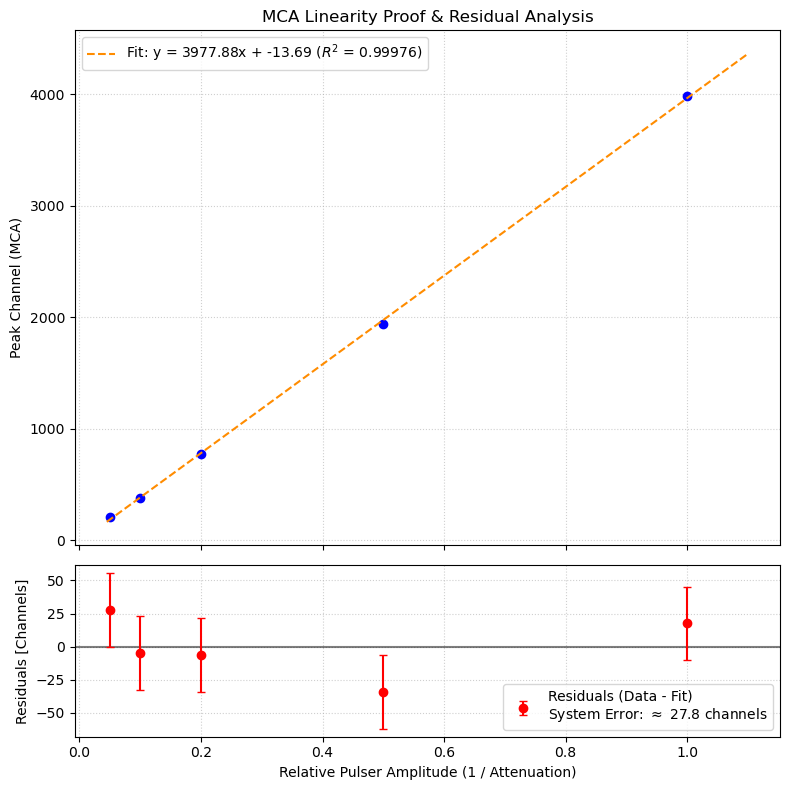

In [9]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# נתיב התיקייה
folder_path = r"C:\Users\chens\OneDrive\שולחן העבודה\School stuff\מסת ניוטרינו\data\attachments\MCA"
TARGET_GAIN = "gain 40 5 "

def linear_model(x, slope, intercept):
    return slope * x + intercept

def gaussian_model(x, amp, mu, sigma):
    return amp * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

def extract_peak_gaussian(filepath):
    try:
        counts = []
        start_reading = False
        with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
            for line in f:
                if "0 4096" in line:
                    start_reading = True
                    continue
                if start_reading:
                    counts.append(float(line.strip()))
        
        if not counts: return None
        counts = np.array(counts)
        channels = np.arange(len(counts))
        
        raw_max = np.argmax(counts)
        window = 30
        start_idx = max(0, raw_max - window)
        end_idx = min(len(counts), raw_max + window)
        
        x_window = channels[start_idx:end_idx]
        y_window = counts[start_idx:end_idx]
        
        initial_guess = [counts[raw_max], raw_max, 10.0]
        popt, _ = curve_fit(gaussian_model, x_window, y_window, p0=initial_guess, maxfev=10000)
        
        return popt[1] # מחזיר את מרכז הגאוסיאן המדויק
    except Exception:
        # גיבוי למקרה שהגאוסיאן נכשל
        return np.argmax(counts) if 'counts' in locals() and counts.size > 0 else None

# איסוף הנתונים
mca_x, mca_y = [], []
for filename in os.listdir(folder_path):
    if not filename.endswith('.txt'): continue
    base_name = os.path.splitext(filename)[0]
    filepath = os.path.join(folder_path, filename)
    
    if base_name.startswith(TARGET_GAIN) and "amp" in base_name:
        try:
            parts = base_name.split("amp")
            if len(parts) >= 2:
                attenuation_factor = float(parts[1].strip().replace('_', '.'))
                amplitude_val = 1.0 / attenuation_factor
                
                # קריאה לפונקציית הגאוסיאן (כמו שצריך להיות!)
                peak = extract_peak_gaussian(filepath) 
                if peak is not None:
                    mca_x.append(amplitude_val)
                    mca_y.append(peak)
        except Exception: pass

x = np.array(mca_x, dtype=float)
y = np.array(mca_y, dtype=float)
sort_idx = np.argsort(x)
x, y = x[sort_idx], y[sort_idx]

if len(x) >= 2:
    # -------------------------------------------------------------
    # 1. התאמה לינארית נקייה ללא משקולות מראש
    # -------------------------------------------------------------
    popt_clean, pcov_clean = curve_fit(linear_model, x, y)
    slope_clean, intercept_clean = popt_clean
    slope_err_clean, intercept_err_clean = np.sqrt(np.diagonal(pcov_clean))
    
    residuals_clean = y - linear_model(x, *popt_clean)
    
    # חישוב R-squared
    ss_res = np.sum(residuals_clean ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    
    # -------------------------------------------------------------
    # 2. הנדסה לאחור לחילוץ השגיאה השיטתית
    # -------------------------------------------------------------
    dof = len(x) - 2
    best_sigma_sys = 0.0
    for sys_err in np.linspace(0.0, 100.0, 5000):
        chisq = np.sum((residuals_clean / sys_err) ** 2) if sys_err > 0 else np.inf
        if chisq / dof <= 1.0:
            best_sigma_sys = sys_err
            break

    print(f"=== MCA Linearity Parameters & Accuracy ===")
    print(f"Slope (a): {slope_clean:.5f} +/- {slope_err_clean:.5f} [Channels / Relative Amp]")
    print(f"Intercept (b): {intercept_clean:.5f} +/- {intercept_err_clean:.5f} [Channels]")
    print(f"R-squared (R^2): {r_squared:.6f}")
    print(f"Extracted System Error (Residual Scatter): {best_sigma_sys:.3f} channels\n")

    # -------------------------------------------------------------
    # 3. יצירת גרף כפול ושמירה
    # -------------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True, 
                                   gridspec_kw={'height_ratios': [3, 1]})
    
    # גרף עליון
    ax1.plot(x, y, 'blue', marker='o', linestyle='') # ללא לייבל
    x_fit = np.linspace(min(x)*0.9, max(x)*1.1, 100)
    equation_label = f'Fit: y = {slope_clean:.2f}x + {intercept_clean:.2f} ($R^2$ = {r_squared:.5f})'
    ax1.plot(x_fit, linear_model(x_fit, *popt_clean), color='darkorange', linestyle='--', label=equation_label)
    ax1.set_ylabel("Peak Channel (MCA)")
    ax1.set_title("MCA Linearity Proof & Residual Analysis")
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend()
    
    # גרף תחתון
    residual_label = f"Residuals (Data - Fit)\nSystem Error: $\\approx$ {best_sigma_sys:.1f} channels"
    # zorder=3 מבטיח שהנקודות יצוירו מעל קו האפס ולא יוסתרו
    ax2.errorbar(x, residuals_clean, yerr=best_sigma_sys, fmt='ro', capsize=3, label=residual_label, zorder=3)
    ax2.axhline(0, color='black', linestyle='-', alpha=0.5, zorder=2)
    ax2.set_xlabel("Relative Pulser Amplitude (1 / Attenuation)")
    ax2.set_ylabel("Residuals [Channels]")
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend()
    
    plt.tight_layout()
    
    # שמירה כקובץ PDF לתמונות חדות וללא פקסול באוברליף
    plt.savefig("mca_linearity_plot.pdf", format='pdf', bbox_inches='tight')
    plt.show()
else:
    print("Not enough valid data points found.")